## **Multi-Class Classification**

We have more than 2 levels (labels). They are mutually exclusive. We use the categorical cross-entropy cost function for the gradient descent algorithm.

**Categorical cross-entropy loss**

The formula is:

$$-\sum y_k log(\hat{p}_k)  $$

In [7]:
import numpy as np
import pandas as pd

## suppose we have y_k = {dog, cat, bird}
## obs 1 - Cat
y = np.array([0,    1,    0])
p = np.array([0.15, 0.75, 0.1]) ## assuming softmax has been used

## categorical cross-entropy loss
## -(0*np.log(0.05) + 1*np.log(0.90) + 0*np.log(0.05))

## categorical cross-entropy loss
np.sum(-y*np.log(p))

np.float64(0.2876820724517809)

In [8]:
## cost function (average)
def categorical_cross_entropy_cost(y, p): ## assuming y and p are matrices
  -np.mean(np.sum(y*np.log(p), axis=1))

## **Example**

Let's predict the account status of customers. We are interested in customers at-risk of leaving the company

In [9]:
df = pd.read_csv('https://raw.githubusercontent.com/martinwg/ISA630/refs/heads/master/data/customer_health.csv')
df.head()

,Monthly_Active_Usage_Hours,Support_Tickets_Open,License_Utilization_Rate,Last_Login_Days_Ago,Contract_Type,Account_Status
0,74.908024,1,0.240685,40,Monthly,At-Risk
1,190.142861,6,0.764156,9,Annual,At-Risk
2,146.398788,1,0.424427,57,Monthly,Inactive
3,119.731697,2,0.704144,16,Annual,Stable
4,31.203728,2,0.343580,16,Multi-year,Stable


In [10]:
## get X matrix and y vector
X = df.drop('Account_Status', axis=1)
y = df['Account_Status']

In [12]:
## dummy encode categorical predictors
X = pd.get_dummies(X, drop_first=True)
X.head()

,Monthly_Active_Usage_Hours,Support_Tickets_Open,License_Utilization_Rate,Last_Login_Days_Ago,Contract_Type_Monthly,Contract_Type_Multi-year
0,74.908024,1,0.240685,40,True,False
1,190.142861,6,0.764156,9,False,False
2,146.398788,1,0.424427,57,True,False
3,119.731697,2,0.704144,16,False,False
4,31.203728,2,0.343580,16,False,True


In [14]:
## on the background
## most common - one-hot encoding
#### dummy-encoding drops one-level
#### one-hot encoding -  a dummy is created for each level
from sklearn.preprocessing import OneHotEncoder
ohe = OneHotEncoder()

y_onehot = ohe.fit_transform(y.values.reshape(-1,1))
y_onehot

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 1000 stored elements and shape (1000, 4)>

In [15]:
## change to dense
y_onehot = y_onehot.toarray()
y_onehot

## this is is what gets used on the background
## if you use sklearn RandomForest
#### rf.fit(X, y)  ## in the background y is converted y_onehot

array([[1., 0., 0., 0.],
       [1., 0., 0., 0.],
       [0., 0., 1., 0.],
       ...,
       [0., 0., 0., 1.],
       [0., 0., 0., 1.],
       [0., 0., 0., 1.]])

In [16]:
## y variable
y.value_counts()

,count
Account_Status,
Stable,547
Inactive,251
At-Risk,182
Expansion-Ready,20


In [23]:
## Logistic Regression
#### LR is a binary classification algorithm (not meant for multi-class)
#### the output is p = (0,1)
#### One vs the Rest (OvR)
#### 4 models, e.g., (Stable vs NOT stable) - (Inactive vs Not Inactive) - etc


from sklearn.linear_model import LogisticRegression

## instance
lr = LogisticRegression(solver = 'newton-cg', max_iter = 1000)

## fit on y - y gets converted to y_onehot on the background
lr.fit(X, y)

LogisticRegression(max_iter=1000, solver='newton-cg')

In [24]:
## multi-class schemes
#### OvR - One vs Rest (most common)
#### OvO - One vs One (more computations, but differentiates better)

from sklearn.multiclass import OneVsRestClassifier, OneVsOneClassifier

## instance OneVsOneClassifier with logistic regression
ovo = OneVsOneClassifier(LogisticRegression(solver = 'newton-cg', max_iter = 1000))

## fit
ovo.fit(X, y)

OneVsOneClassifier(estimator=LogisticRegression(max_iter=1000,
                                                solver='newton-cg'))

In [25]:
## predictions
yhat = ovo.predict(X)

In [26]:
yhat

array(['Inactive', 'Stable', 'Inactive', 'Stable', 'Stable', 'At-Risk',
       'Stable', 'Inactive', 'Stable', 'Stable', 'Stable', 'Stable',
       'Stable', 'Stable', 'Stable', 'Stable', 'Stable', 'Stable',
       'Inactive', 'Stable', 'Stable', 'Stable', 'Stable', 'Stable',
       'Stable', 'Stable', 'Stable', 'Stable', 'At-Risk', 'Stable',
       'Inactive', 'Stable', 'Inactive', 'Stable', 'At-Risk', 'Stable',
       'At-Risk', 'Inactive', 'At-Risk', 'Inactive', 'Inactive', 'Stable',
       'Stable', 'At-Risk', 'Stable', 'Inactive', 'Stable', 'Stable',
       'Stable', 'Inactive', 'Stable', 'Stable', 'Inactive', 'Inactive',
       'Inactive', 'Stable', 'Stable', 'Stable', 'Inactive', 'Inactive',
       'Stable', 'Stable', 'At-Risk', 'Stable', 'Stable', 'Stable',
       'Stable', 'Stable', 'Stable', 'At-Risk', 'At-Risk', 'Inactive',
       'At-Risk', 'Stable', 'Stable', 'Stable', 'Inactive', 'Inactive',
       'Stable', 'Stable', 'Inactive', 'Inactive', 'Stable', 'Stable',
       'In

In [29]:
## probability
#### decision function
#### softmax is applied to each obs
phat = ovo.decision_function(X)
phat

array([[ 2.28426507, -0.32005848,  3.30323909,  1.29726048],
       [ 2.16132904,  1.30707825, -0.32045072,  3.30815858],
       [ 0.76747179, -0.31304104,  3.31232034,  2.24720321],
       ...,
       [ 0.7374473 , -0.31967371,  2.30335937,  3.31480601],
       [ 0.8131469 ,  2.29238842, -0.31426478,  3.30463577],
       [ 3.3035136 ,  0.69682746, -0.31180906,  2.31163193]])

In [31]:
#### sofmax
phat1 = np.array([ 2.28426507, -0.32005848,  3.30323909,  1.29726048])
np.exp(phat1)/np.sum(np.exp(phat1))

array([0.23713566, 0.01753693, 0.656949  , 0.08837842])

In [ ]:
#### the prediction is the highest probability
###### doesn't mean an observation has to have a prob > 0.5 to be assigned a given level
[0.25, 0.24, 0.26 , 0.25]

**Metrics**

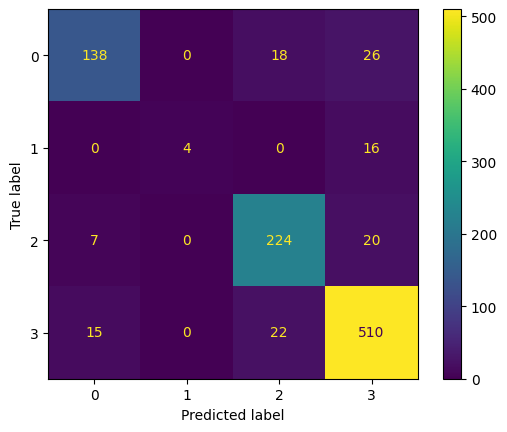

In [32]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

 (confusion_matrix(y, yhat)).plot()

In [33]:
## accuracy
from sklearn.metrics import accuracy_score

accuracy_score(y, yhat)

0.876

In [35]:
## recall (detection rate, sensitivity)
from sklearn.metrics import recall_score

recall_score(y, yhat, average='macro')

0.6957575888062351

# Task
Implement a multi-class classification neural network using TensorFlow, preparing `X` and `y_onehot` for training and testing, defining and compiling a sequential Keras model with appropriate layers and loss function, training the model, and then evaluating its performance using accuracy, a confusion matrix, and a classification report.

## Prepare data for TensorFlow

### Subtask:
Convert `X` and `y_onehot` to TensorFlow-compatible formats and split the data into training and testing sets.


**Reasoning**:
To prepare the data for TensorFlow, I need to convert the `X` DataFrame to a NumPy array, then split both `X` and `y_onehot` into training and testing sets using `train_test_split` as per the instructions.



In [36]:
from sklearn.model_selection import train_test_split

# Convert X DataFrame to a NumPy array
X_numpy = X.values

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_numpy, y_onehot, test_size=0.2, random_state=42)

print("Data splitting complete. Shapes of the resulting datasets:")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

Data splitting complete. Shapes of the resulting datasets:
X_train shape: (800, 6)
X_test shape: (200, 6)
y_train shape: (800, 4)
y_test shape: (200, 4)


## Define and compile TensorFlow model

### Subtask:
Create a sequential TensorFlow Keras model. This will include input, hidden, and output layers with appropriate activation functions (e.g., ReLU for hidden, Softmax for output). Then, compile the model specifying an optimizer, the `categorical_crossentropy` loss function, and accuracy metrics.


**Reasoning**:
I will import the necessary TensorFlow Keras components, determine the input and output dimensions, define a sequential model with input, hidden, and output layers, and then compile it with the specified optimizer, loss function, and metrics.



In [37]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras import optimizers

# Determine the number of input features and output classes
input_features = X_train.shape[1]
output_classes = y_train.shape[1]

# Instantiate a Sequential Keras model
model = Sequential()

# Add Input layer
model.add(Input(shape=(input_features,)))

# Add at least one Dense hidden layer with 'relu' activation
model.add(Dense(128, activation='relu')) # Using 128 units as an example
model.add(Dense(64, activation='relu')) # Adding another hidden layer for more complexity

# Add a Dense output layer with 'softmax' activation
model.add(Dense(output_classes, activation='softmax'))

# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

print("TensorFlow Keras model defined and compiled successfully.")
model.summary()

TensorFlow Keras model defined and compiled successfully.


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,412 (36.77 KB)

 Trainable params: 9,412 (36.77 KB)

 Non-trainable params: 0 (0.00 B)